**Anes's Notebook: Last commit: 12/08/2024**

---



## I) Model Selection Best Practices
This project explores different ways of detecting phishing URLs, we're going to compare some solutions.

Based on research, LSTMs CNNs and transformers are considered advanced for this task, but given limited resources and time, a Machine Learning approach is more feasible as a start.

I will compare the following ML models at first:

*   Random Forest
*   Logistic Regression (fastest)

Then I will explore DL models:

*   CNN
*   RNN : LSTM

The key metrics for optimization, in order of priority, are:

*   Recall on the phishing class
*   Precision on the legit class
*   Overall F1 score or weighted F1 score


---
##II) Quick Exploratory Data Analysis (EDA)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files

upload = files.upload()

Saving test_data_to_send.csv to test_data_to_send.csv
Saving training_data.csv to training_data.csv


In [ ]:
train_data = pd.read_csv('training_data.csv')
test_data_to_send = pd.read_csv('test_data_to_send.csv')

In [ ]:
train_data.head()

,URL,Label
0,tubevector.com/search/?q=erika,good
1,classmates.com/directory/school/Marian%20Chris...,good
2,manufacturersnews.com/executives.asp?start=CEN,good
3,skycity.com.tw/down/ArcSoft/wrar36b8tc.exe,bad
4,projekt30.com/,good


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254125 entries, 0 to 254124
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     254125 non-null  object
 1   Label   254125 non-null  object
dtypes: object(2)
memory usage: 3.9+ MB


In [ ]:
train_data.isnull().sum()

,0
URL,0
Label,0


In [ ]:
train_data.loc[train_data['Label']=='good', 'Label'] = 0
train_data.loc[train_data['Label']=='bad', 'Label'] = 1

train_data['Label'] = pd.to_numeric(train_data['Label'])

print('length of the dataset:', len(train_data))
train_data.head()

length of the dataset: 254125


,URL,Label
0,tubevector.com/search/?q=erika,0
1,classmates.com/directory/school/Marian%20Chris...,0
2,manufacturersnews.com/executives.asp?start=CEN,0
3,skycity.com.tw/down/ArcSoft/wrar36b8tc.exe,1
4,projekt30.com/,0


The `training_data` is long and thorough enough to separate it into training

and testing samples.



In [ ]:
print('length of the dataset:', len(test_data_to_send))
test_data_to_send.head()

length of the dataset: 57101


,URL
0,gracechurchstaffordsprings.org/
1,trailers.apple.com/trailers/wb/iamlegendawaken...
2,baseball-almanac.com/players/player.php?p=lowe...
3,lib.berkeley.edu/MRC/scifibib.html
4,syamasahithi.com/8fh34f3


We check if the dataset and the label is well balanced

In [ ]:
suspicious = train_data.loc[train_data["Label"] == 1].copy()
good = train_data.loc[train_data["Label"] == 0].copy()
print('nbr of suspicious emails:',len(suspicious))
print('nbr of good emails:',len(good))
print('percentage of suspicious email:',100*len(suspicious)/len(good+suspicious))

nbr of suspicious emails: 29088
nbr of good emails: 225037
percentage of suspicious email: 11.4463354648303


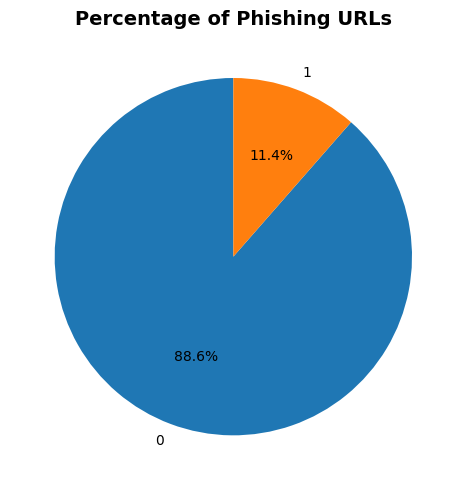

In [ ]:
def plot_label_pie(df: pd.DataFrame, label_col: str = 'Label', title: str = 'Label Distribution (Percentage)', figsize: tuple = (7, 5)):

    if label_col not in df.columns:
        print(f"Error: Column '{label_col}' not found in the DataFrame.")
        return

    label_counts = df[label_col].value_counts()

    if label_counts.empty:
        print(f"No data found in the '{label_col}' column.")
        return

    fig, ax1 = plt.subplots(1, 1, figsize=figsize)

    ax1.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
    ax1.set_title(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_label_pie(train_data, label_col='Label', title='Percentage of Phishing URLs')

We need balanced data before training the models: using SMOTE or class_weight='balanced'

---
exploring the features of the dataset:

In [ ]:
suspicious['length'] = suspicious['URL'].apply(lambda x: len(x))
good['length'] = good['URL'].apply(lambda x: len(x))

average_length_good = good['length'].mean()
average_length_suspicious = suspicious['length'].mean()

print("Average length of 'good' URLs:", average_length_good)
print("Average length of 'suspicious' URLs:", average_length_suspicious)

Average length of 'good' URLs: 45.661766731693014
Average length of 'suspicious' URLs: 63.30840896589659


In [ ]:
train_data_len = train_data.copy()
train_data_len['length'] = train_data_len['URL'].apply(lambda x: len(x))
train_data_len.head()

,URL,Label,length
0,tubevector.com/search/?q=erika,0,30
1,classmates.com/directory/school/Marian%20Chris...,0,76
2,manufacturersnews.com/executives.asp?start=CEN,0,46
3,skycity.com.tw/down/ArcSoft/wrar36b8tc.exe,1,42
4,projekt30.com/,0,14


In [ ]:
train_data.loc[train_data['URL'].str.contains('.exe')]

,URL,Label
2,manufacturersnews.com/executives.asp?start=CEN,0
3,skycity.com.tw/down/ArcSoft/wrar36b8tc.exe,1
114,scsofiaspb.ru/services/40.exe,1
481,romana.fi/56gf/g545.exe,1
1265,tripadvisor.com/ShowUserReviews-g155032-d15531...,0
...,...,...
252709,iophanti.hurryaccompany.ru/Google_Mail_Checker...,1
252735,my.execpc.com/~gopalan/mts/mtsclient.html,0
253125,feelingsoftware.com/about-us/executive-team.ht...,0
253263,2696666.com/43rf3dw/34frgegrg.exe,1


In [ ]:
train_data.loc[train_data['URL'].str.endswith('.exe')]

,URL,Label
3,skycity.com.tw/down/ArcSoft/wrar36b8tc.exe,1
114,scsofiaspb.ru/services/40.exe,1
481,romana.fi/56gf/g545.exe,1
1311,slimxxxtubefzc.ddns.name/2013/girl-fucked-by-d...,1
1707,juanpedroperez.com/fotos/photos/xfs_extension.exe,1
...,...,...
251973,newsumbrella.net/ne3s/file.exe,1
252373,franny.goadultgame.ru/js/boxun4.exe,1
252486,directxex.com/uploads/1599687595.ms.exe?dl=115...,1
252709,iophanti.hurryaccompany.ru/Google_Mail_Checker...,1


not all ".exe" are bad, only those that end with ".exe"



In [ ]:
train_data.loc[train_data['URL'].str.contains('wikipedia') & train_data['Label'] == 1]

,URL,Label
32675,83.220.171.223/wikipedia/upload.php,1
86289,northcarolinaarea.com/vmware/wikipedia/service...,1


Wikipedia is not a reliable keyword for filtering.

We could use regular expressions (regex) to identify certain patterns (such as safe words or banned patterns), but due to time constraints, I won’t implement that for now. It would be a good exploratory approach to consider if more time were available.

---

##III) Unsupervised Learning Analysis (PCA + Clustering):

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

K=4 # I choose 4 Clusters because it produced 3 clusters with 0% phishing which we could then analyze

vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=1000)
X_tfidf = vectorizer.fit_transform(train_data['URL'])

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_tfidf.toarray())

kmeans = KMeans(n_clusters=K, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df = train_data.copy()
df['cluster'] = clusters

In [ ]:
cluster_stats = df.groupby('cluster').agg({
    'Label': ['count', 'mean'],
    'URL': lambda x: x.str.len().mean()
}).round(3)

cluster_stats.columns = ['Count', 'Phishing_Rate', 'Avg_URL_Length']
print(cluster_stats)

for i in range(K):
    print(f"\n=== CLUSTER {i} ===")
    cluster_urls = df[df['cluster'] == i]['URL'].head(5)
    for url in cluster_urls:
        print(f"  {url}")

          Count  Phishing_Rate  Avg_URL_Length
cluster                                       
0        232857          0.124          48.314
1          9784          0.000          42.037
2          6054          0.000          31.353
3          5430          0.020          48.952

=== CLUSTER 0 ===
  tubevector.com/search/?q=erika
  classmates.com/directory/school/Marian%20Christian%20High%20School?org=19858
  manufacturersnews.com/executives.asp?start=CEN
  skycity.com.tw/down/ArcSoft/wrar36b8tc.exe
  projekt30.com/

=== CLUSTER 1 ===
  en.wikipedia.org/wiki/Lai_Vung
  en.wikipedia.org/wiki/Category:Mobile_technology
  en.wikipedia.org/wiki/McCarthy_Tetrault
  en.wikipedia.org/wiki/MathML
  en.wikipedia.org/wiki/Limocar

=== CLUSTER 2 ===
  youtube.com/watch?v=4eONt5IOiBg
  youtube.com/watch?v=WBNdRbsWAlg
  youtube.com/watch?v=km1-6CGszto
  youtube.com/watch?v=DP_ZbkUsZWo
  youtube.com/watch?v=7-yK1v2hIKs

=== CLUSTER 3 ===
  maxparkblog.blogspot.com/2010/12/maxwell-parks-most-famous

Cluster 1-2-3 only contains good URLs, we can check the pattern of that class

We can then proceed to analyzing the pattern in the clusters with 0% phishing, that way we can maybe find "safe words" or patterns.

In [ ]:
one_hundred_p = df.loc[df['cluster'] == 1].copy()
one_hundred_p

,URL,Label,cluster
21,en.wikipedia.org/wiki/Lai_Vung,0,1
47,en.wikipedia.org/wiki/Category:Mobile_technology,0,1
67,en.wikipedia.org/wiki/McCarthy_Tetrault,0,1
77,en.wikipedia.org/wiki/MathML,0,1
103,en.wikipedia.org/wiki/Limocar,0,1
...,...,...,...
253945,en.wikipedia.org/wiki/Kevin_Poulin,0,1
253947,en.wikipedia.org/wiki/Jean_Crowder,0,1
254018,en.wikipedia.org/wiki/List_of_Quebec_film_dire...,0,1
254053,en.wikipedia.org/wiki/June_Clark,0,1


In [ ]:
one_hundred_p.loc[
    ~(one_hundred_p['URL'].str.contains('en.wikipedia.org'))
]

,URL,Label,cluster
496,ang.wikipedia.org/wiki/Washington_Freedom,0,1
1378,simple.wikipedia.org/wiki/Tochigi_Prefecture,0,1
1522,allrss.com/wikipedia.php?title=Japan_at_the_19...,0,1
1727,wikimapia.org/11804/Ordway-Building,0,1
1952,trueknowledge.com/q/garrett_backstrom_wikipedia,0,1
...,...,...,...
251640,www.freedesktop.org/wiki/OpenIcc,0,1
251885,ballotpedia.org/wiki/index.php?title=Christine...,0,1
252479,simple.wikipedia.org/wiki/Single_Ladies_(Put_a...,0,1
252805,flaggedrevs.labs.wikimedia.org/wiki/Ronald_Reagan,0,1


In [ ]:
one_hundred_p.loc[
    (one_hundred_p['URL'].str.contains('wikipedia')) &
    (one_hundred_p['Label'] == 1)
]

,URL,Label,cluster
32675,83.220.171.223/wikipedia/upload.php,1,1


En général wikipédia est safe dans cette database, il est dangereux une fois associé a un .php et une ip.

We see that with more complex feature engineering (including URL length, character counts, and structural patterns) we can enhance the dataset to help ML algorithms detect fraudulent URLs more effectively

-----

##IV) Machine Learning Models:

1.   RandomForest



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, recall_score, precision_score, classification_report
from sklearn.model_selection import GridSearchCV


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train_data['URL'], train_data['Label'], test_size=0.2, random_state=42, stratify=train_data['Label'])

I use a pipeline to automate vectorization and avoid forgetting it (on y_pred among others).

And GridSearchCV to search for optimal hyperparameters.

In [ ]:
import time

In [ ]:
#Pipeline_RandomForest:

pipeline_RF= Pipeline([
    ('tfidf',TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features = 50000)),
    ('classifier', RandomForestClassifier(n_estimators= 100, class_weight='balanced'))
])
start = time.time()
pipeline_RF.fit(X_train, y_train)
print("Done in", round(time.time() - start, 2), "seconds")

y_pred_RF = pipeline_RF.predict(X_test)

print(classification_report(y_test, y_pred_RF))

Done in 551.21 seconds
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     45007
           1       0.94      0.85      0.89      5818

    accuracy                           0.98     50825
   macro avg       0.96      0.92      0.94     50825
weighted avg       0.98      0.98      0.98     50825



since we don't use smote + class_weight at the same time

In [ ]:
#from imblearn.over_sampling import SMOTE

#smote = SMOTE(random_state=42)
#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#print("Shape of X_train before SMOTE:", X_train.shape)
#print("Shape of X_train after SMOTE:", X_train_smote.shape)
#print("\nLabel distribution before SMOTE:\n", y_train.value_counts())
#print("\nLabel distribution after SMOTE:\n", y_train_smote.value_counts())

In [ ]:
#from imblearn.pipeline import Pipeline
#from imblearn.over_sampling import SMOTE

#pipeline_RF_SMOTE = Pipeline([
    #('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features = 50000)),
    #('smote', SMOTE(random_state=42)), we don't use smote + class_weight at the same time
    #('classifier', RandomForestClassifier(n_estimators= 100, class_weight='balanced'))
#])

#start = time.time()
#pipeline_RF_SMOTE.fit(X_train, y_train)
#print("Done in", round(time.time() - start, 2), "seconds")

#y_pred_RF_SMOTE = pipeline_RF_SMOTE.predict(X_test)

#print(classification_report(y_test, y_pred_RF_SMOTE))

Done in 554.27 seconds
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     45007
           1       0.94      0.84      0.89      5818

    accuracy                           0.98     50825
   macro avg       0.96      0.92      0.94     50825
weighted avg       0.98      0.98      0.98     50825



*Hyperparameters* Optimisation

In [ ]:
pipeline_H = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=50000)),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

param_grid = {
    'classifier__min_samples_split': [5, 10, 20],
    'classifier__max_depth': [500, 750, 1000]
}

scoring = {
    'f1_weighted': 'f1_weighted',
    'recall_phishing': make_scorer(recall_score, pos_label=1),
    'precision_legit': make_scorer(precision_score, pos_label=0)
}

grid = GridSearchCV(pipeline_H, param_grid, cv=3, scoring=scoring, refit="f1_weighted", n_jobs=-1, verbose=2)



start = time.time()
grid.fit(X_train, y_train)
print("Done in", round(time.time() - start, 2), "seconds")


print("Best parameters: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Done in 2490.26 seconds
Best parameters:  {'classifier__max_depth': 500, 'classifier__min_samples_split': 10}
Best score:  0.9726174477663357


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Done in 2490.26 seconds
Best parameters:  {'classifier__max_depth': 500, 'classifier__min_samples_split': 10}
Best score:  0.9726174477663357

In [ ]:
y_pred_RFH = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_RFH))

NameError: name 'grid' is not defined

In [ ]:
#to launch during the night to save the model
#import pickle

#with open('RF_gridsearch_2.pkl', 'wb') as f:
#    pickle.dump(grid.best_estimator_, f)

#files.download('RF_gridsearch_2.pkl')

Confusion Matrix:

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
#import pickle
#from google.colab import files

#upload_models = files.upload()

#pipeline_RF = pickle.load(open('RF_gridsearch.pkl', 'rb'))

#y_pred_RFH = pipeline_RF.predict(X_test)

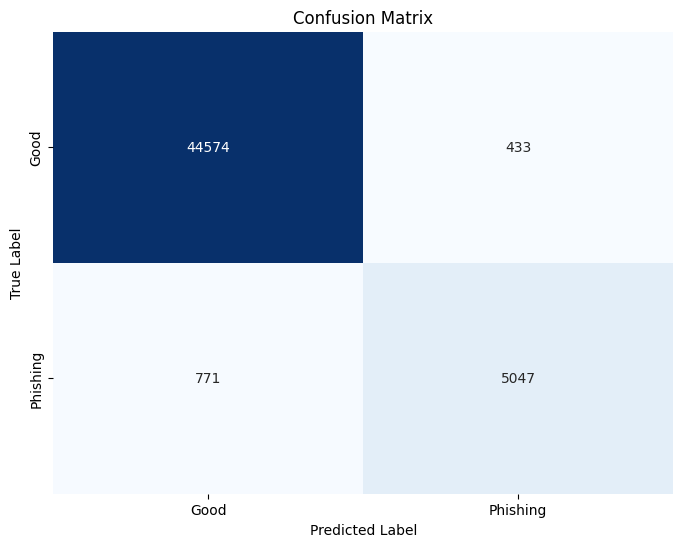

In [ ]:
matrix = confusion_matrix(y_test, y_pred_RFH) # y_pred_RFH to use the enhanced Random Forest

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=['Good', 'Phishing'], yticklabels=['Good', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

---

2.   Logistic Regression:


Linear model, should take less time to train than RandomForest

In [ ]:
pipeline_LR = Pipeline([
    ('tfidf',TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features = 50000)),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

start = time.time()
pipeline_LR.fit(X_train, y_train)
print("Done in", round(time.time() - start, 2), "seconds")

y_pred_LR = pipeline_LR.predict(X_test)

print(classification_report(y_test, y_pred_LR))

Done in 31.43 seconds
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     45007
           1       0.81      0.94      0.87      5818

    accuracy                           0.97     50825
   macro avg       0.90      0.95      0.93     50825
weighted avg       0.97      0.97      0.97     50825



3.Model Comparison (RF vs LR)

In [ ]:
#if you have the models uploaded no need to re-upload.

#import pickle
#from google.colab import files

#upload_models = files.upload()

#pipeline_LR = pickle.load(open('LR_model.pkl', 'rb'))
#pipeline_RF = pickle.load(open('RF_gridsearch.pkl', 'rb'))

Saving RF_gridsearch.pkl to RF_gridsearch.pkl
Saving LR_model.pkl to LR_model.pkl


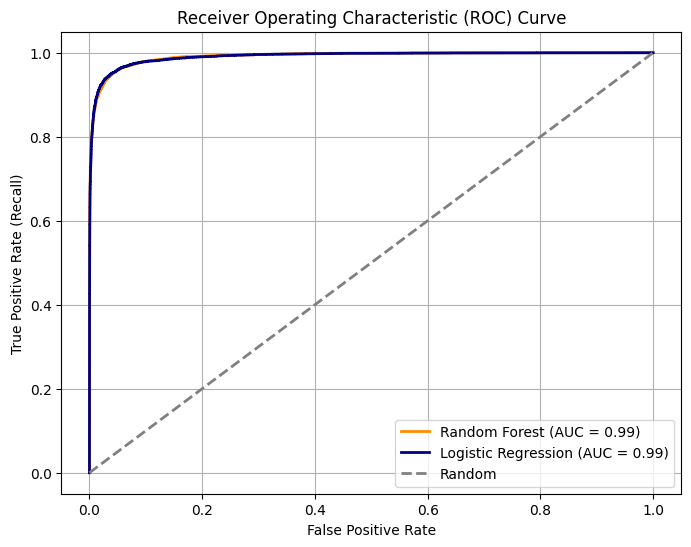

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


y_pred_prob_rf = pipeline_RF.predict_proba(X_test)[:, 1]
y_pred_prob_lr = pipeline_LR.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_lr, tpr_lr, color='navy', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random') # jauge : droite pour juger
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

---

VI) Deep Learning Models:

1.   CNN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, padding="post")
X_test_pad = pad_sequences(X_test_seq, padding="post")

print("\n -----train----")
print(X_train_pad[0])
print(X_train_pad.shape)
print("\n -----test----")
print(X_test_pad[0])
print(X_test_pad.shape)


 -----train----
[ 1671     2   141  2024 55926    15   400    32  2836     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0]
(203300, 156)

 -----test----
[20

In [ ]:
#from sklearn.utils.class_weight import compute_class_weight

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100
input_length = X_train_pad.shape[1]

In [ ]:
model_cnn = tf.keras.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=input_length),

        layers.Conv1D(128, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 4, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 5, activation='relu'),
        layers.GlobalMaxPooling1D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])


model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

model_cnn.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.9553 - loss: 0.1289 - precision: 0.8716 - recall: 0.6934 - val_accuracy: 0.9808 - val_loss: 0.0542 - val_precision: 0.9605 - val_recall: 0.8655
Epoch 2/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9977 - loss: 0.0077 - precision: 0.9916 - recall: 0.9886 - val_accuracy: 0.9794 - val_loss: 0.0741 - val_precision: 0.9398 - val_recall: 0.8732
Epoch 3/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9996 - loss: 0.0015 - precision: 0.9982 - recall: 0.9985 - val_accuracy: 0.9775 - val_loss: 0.1056 - val_precision: 0.8995 - val_recall: 0.9007
Epoch 4/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9996 - loss: 0.0013 - precision: 0.9980 - recall: 0.9987 - val_accuracy: 0.9799 - val_loss: 0.1173 - val_precision: 0.9403 - val_recall: 0.8773
Epoch 5/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9999 - loss: 4.8918e-04 - precision: 0.9993 - recall: 0.9996 - val_accuracy: 0.

In [ ]:

y_pred_prob_cnn = model_cnn.predict(X_test_pad)

y_pred_binary_cnn = (y_pred_prob_cnn > 0.5).astype(int)


print(classification_report(y_test, y_pred_binary_cnn))

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     45007
           1       0.95      0.88      0.91      5818

    accuracy                           0.98     50825
   macro avg       0.97      0.94      0.95     50825
weighted avg       0.98      0.98      0.98     50825



we can play with the threshold to see which value has the best precision + recall

In [ ]:
#from sklearn.metrics import precision_recall_curve

#precision, recall, thresholds = precision_recall_curve(y_test2, y_pred_prob_cnn)

#plt.figure(figsize=(8, 6))
#plt.plot(thresholds, precision[:-1], label='Precision')
#plt.plot(thresholds, recall[:-1], label='Recall')
#plt.xlabel('Threshold')
#plt.ylabel('Score')
#plt.legend()
#plt.grid(True)
#plt.show()

#for threshold in [0.3, 0.4, 0.5, 0.6]:
#    y_pred = (y_pred_prob_cnn > threshold).astype(int)
#    print(f"\n--- Seuil = {threshold} ---")
#    print(classification_report(y_test2, y_pred))

2.   LSTM:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from tensorflow.keras.layers import Bidirectional

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

model_lstm.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5083/5083 ━━━━━━━━━━━━━━━━━━━━ 150s 28ms/step - accuracy: 0.9541 - loss: 0.1320 - precision: 0.8708 - recall: 0.6776 - val_accuracy: 0.9812 - val_loss: 0.0555 - val_precision: 0.9500 - val_recall: 0.8795
Epoch 2/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 144s 28ms/step - accuracy: 0.9976 - loss: 0.0078 - precision: 0.9895 - recall: 0.9890 - val_accuracy: 0.9768 - val_loss: 0.0665 - val_precision: 0.8924 - val_recall: 0.9033
Epoch 3/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 143s 28ms/step - accuracy: 0.9996 - loss: 0.0015 - precision: 0.9978 - recall: 0.9983 - val_accuracy: 0.9766 - val_loss: 0.0794 - val_precision: 0.8828 - val_recall: 0.9140
Epoch 4/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 143s 28ms/step - accuracy: 0.9999 - loss: 4.7781e-04 - precision: 0.9996 - recall: 0.9993 - val_accuracy: 0.9756 - val_loss: 0.0871 - val_precision: 0.8969 - val_recall: 0.8850
Epoch 5/10
5083/5083 ━━━━━━━━━━━━━━━━━━━━ 142s 28ms/step - accuracy: 1.0000 - loss: 1.5882e-04 - precision: 0.9999 - recall: 0.9998 - val_accuracy:

In [ ]:
y_pred_prob_lstm = model_lstm.predict(X_test_pad)

y_pred_binary_lstm = (y_pred_prob_lstm > 0.5).astype(int)


print(classification_report(y_test, y_pred_binary_lstm))

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     45007
           1       0.97      0.83      0.90      5818

    accuracy                           0.98     50825
   macro avg       0.98      0.91      0.94     50825
weighted avg       0.98      0.98      0.98     50825



In [ ]:
#to save and serialize the models:

import pickle

with open('cnn_model_final.pkl', 'wb') as f:
    pickle.dump(model_cnn, f)

with open('lstm_model_final.pkl', 'wb') as f:
    pickle.dump(model_lstm, f)

In [ ]:
#to download the models

from google.colab import files

files.download('cnn_model_final.pkl')

files.download('lstm_model_final.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3.   Model Comparison (CNN vs LSTM):



In [ ]:
#import pickle
#from google.colab import files

#upload_models = files.upload()

#model_cnn = pickle.load(open('cnn_model_final.pkl', 'rb'))
#model_lstm = pickle.load(open('lstm_model_final.pkl', 'rb'))

Saving cnn_model.pkl to cnn_model.pkl
Saving lstm_model.pkl to lstm_model.pkl


1589/1589 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step


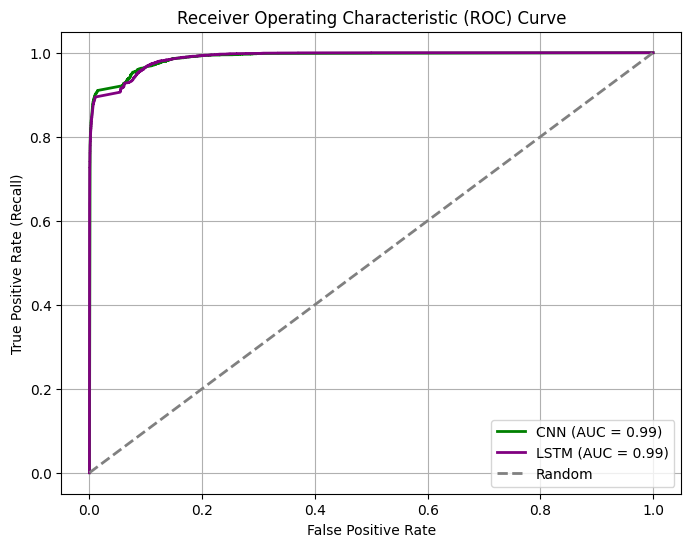

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob_cnn = model_cnn.predict(X_test_pad)
y_pred_prob_lstm = model_lstm.predict(X_test_pad)

if y_pred_prob_cnn.ndim > 1:
    y_pred_prob_cnn = y_pred_prob_cnn.ravel()
if y_pred_prob_lstm.ndim > 1:
    y_pred_prob_lstm = y_pred_prob_lstm.ravel()



fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_prob_lstm)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, color='green', lw=2, label=f'CNN (AUC = {auc_cnn:.2f})')
plt.plot(fpr_lstm, tpr_lstm, color='purple', lw=2, label=f'LSTM (AUC = {auc_lstm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random') # Diagonal line for random classifier

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

good models high AUC, high recall.



---

##IIX) Save and serialize the models

We save the models, since the training process is too long

In [ ]:
#import pickle

#with open('lstm_model_final.pkl', 'wb') as f:
#    pickle.dump(model_lstm, f)

#with open('cnn_model_final.pkl', 'wb') as f:
#    pickle.dump(model_cnn, f)

#with open('RF_model.pkl', 'wb') as f:
#    pickle.dump(pipeline_RF, f)

#with open('LR_model.pkl', 'wb') as f:
#    pickle.dump(pipeline_LR, f)

You can then load the model later using:

In [ ]:
#model = pickle.load(open('random_forest_model.pkl', 'rb'))

#new_url = "http://example.com"

#prediction = model.predict([new_url])

#print("Prediction:", prediction)

In [ ]:
#to download the models
#from google.colab import files

#files.download('lstm_model_final.pkl')

#files.download('cnn_model_final.pkl')

#files.download('RF_model.pkl')

#files.download('LR_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

##IX) Choosing a model:

In [ ]:
#if you executed everything above there is no need to upload the models again

#import pickle

#upload_models = files.upload()

#pipeline_LR = pickle.load(open('LR_model.pkl', 'rb'))
#pipeline_RF = pickle.load(open('RF_gridsearch.pkl', 'rb'))
#model_lstm = pickle.load(open('lstm_model_final.pkl', 'rb'))
#model_cnn = pickle.load(open('cnn_model_final.pkl', 'rb'))

Saving RF_gridsearch.pkl to RF_gridsearch.pkl
Saving LR_model.pkl to LR_model.pkl


In [ ]:
y_pred_RFH = pipeline_RF.predict(X_test)
y_pred_LR = pipeline_LR.predict(X_test)
y_pred_binary_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype(int)
y_pred_binary_cnn = (model_cnn.predict(X_test_pad) > 0.5).astype(int)

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
print("--- RF: ---------------------------------------------")
print(classification_report(y_test, y_pred_RFH))
print("\n--- LR: -------------------------------------------")
print(classification_report(y_test, y_pred_LR))
print("\n--- CNN: ------------------------------------------")
print(classification_report(y_test, y_pred_binary_cnn))
print("\n--- LSTM: -----------------------------------------")
print(classification_report(y_test, y_pred_binary_lstm))

--- RF: ---------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     45007
           1       0.92      0.87      0.89      5818

    accuracy                           0.98     50825
   macro avg       0.95      0.93      0.94     50825
weighted avg       0.98      0.98      0.98     50825


--- LR: -------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     45007
           1       0.81      0.94      0.87      5818

    accuracy                           0.97     50825
   macro avg       0.90      0.95      0.93     50825
weighted avg       0.97      0.97      0.97     50825


--- CNN: ------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     45007
           1       0.95      0.88      0.91      5818

    accuracy          

SO FAR , according to the instructions, the model should have the lowest false positives (i.e., the highest precision) to avoid blocking legitimate URLs, and the highest recall to effectively detect phishing threats. Therefore, I will select the model with the best F1-score, as it balances both precision and recall,

 which in this case is the CNN, again SO FAR.

In addition, it is the most promising model, as we can add more layers to handle more complex patterns, and increase the number of epochs to improve learning.

---

##X) Model Deployment

***Results on test data:***

1.   Random Forest:



In [ ]:
test_data_to_send_RF = test_data_to_send.copy()
test_data_to_send_RF['Label'] = pipeline_RF.predict(test_data_to_send['URL'])
test_data_to_send_RF.head()

,URL,Label
0,gracechurchstaffordsprings.org/,0
1,trailers.apple.com/trailers/wb/iamlegendawaken...,0
2,baseball-almanac.com/players/player.php?p=lowe...,0
3,lib.berkeley.edu/MRC/scifibib.html,0
4,syamasahithi.com/8fh34f3,1


In [ ]:
test_data_to_send.head() #checked

,URL
0,gracechurchstaffordsprings.org/
1,trailers.apple.com/trailers/wb/iamlegendawaken...
2,baseball-almanac.com/players/player.php?p=lowe...
3,lib.berkeley.edu/MRC/scifibib.html
4,syamasahithi.com/8fh34f3


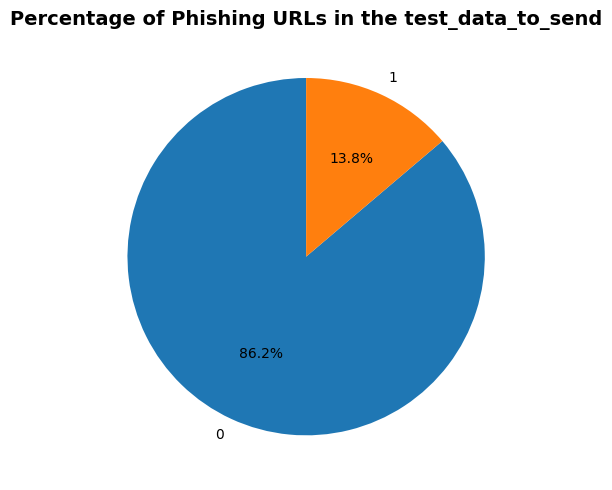

In [ ]:
plot_label_pie(test_data_to_send_RF, label_col='Label', title='Percentage of Phishing URLs in the test_data_to_send')

2.   Logistic Regression:


In [ ]:
test_data_to_send_LR = test_data_to_send.copy()
test_data_to_send_LR['Label'] = pipeline_LR.predict(test_data_to_send['URL'])
test_data_to_send_LR.head()

,URL,Label
0,gracechurchstaffordsprings.org/,0
1,trailers.apple.com/trailers/wb/iamlegendawaken...,0
2,baseball-almanac.com/players/player.php?p=lowe...,0
3,lib.berkeley.edu/MRC/scifibib.html,0
4,syamasahithi.com/8fh34f3,1


In [ ]:
test_data_to_send.head()#checked

,URL
0,gracechurchstaffordsprings.org/
1,trailers.apple.com/trailers/wb/iamlegendawaken...
2,baseball-almanac.com/players/player.php?p=lowe...
3,lib.berkeley.edu/MRC/scifibib.html
4,syamasahithi.com/8fh34f3


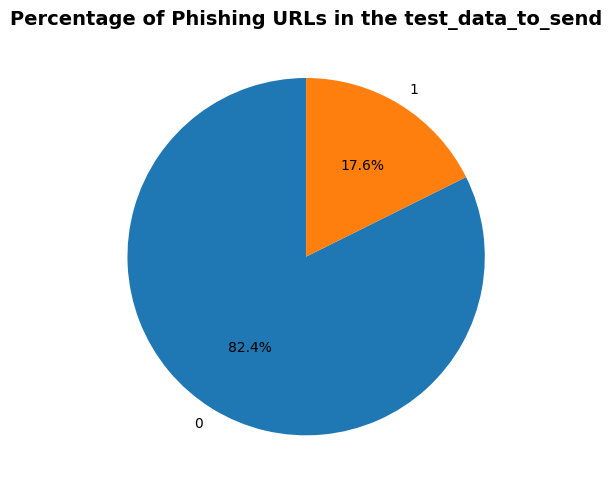

In [ ]:
plot_label_pie(test_data_to_send_LR, label_col='Label', title='Percentage of Phishing URLs in the test_data_to_send')

3.   CNN:


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
#avec le tokenizer d'entrainement
test_sequences_cnn = tokenizer.texts_to_sequences(test_data_to_send['URL'])
test_padded_cnn = pad_sequences(test_sequences_cnn, padding="post")
cnn_predictions_prob = model_cnn.predict(test_padded_cnn)

test_data_to_send_CNN = test_data_to_send.copy()
test_data_to_send_CNN['Label'] = (cnn_predictions_prob > 0.5).astype(int).flatten()
test_data_to_send_CNN.head()

1785/1785 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


,URL,Label
0,gracechurchstaffordsprings.org/,0
1,trailers.apple.com/trailers/wb/iamlegendawaken...,1
2,baseball-almanac.com/players/player.php?p=lowe...,0
3,lib.berkeley.edu/MRC/scifibib.html,0
4,syamasahithi.com/8fh34f3,1


In [ ]:
test_data_to_send.head()#checked

,URL
0,gracechurchstaffordsprings.org/
1,trailers.apple.com/trailers/wb/iamlegendawaken...
2,baseball-almanac.com/players/player.php?p=lowe...
3,lib.berkeley.edu/MRC/scifibib.html
4,syamasahithi.com/8fh34f3


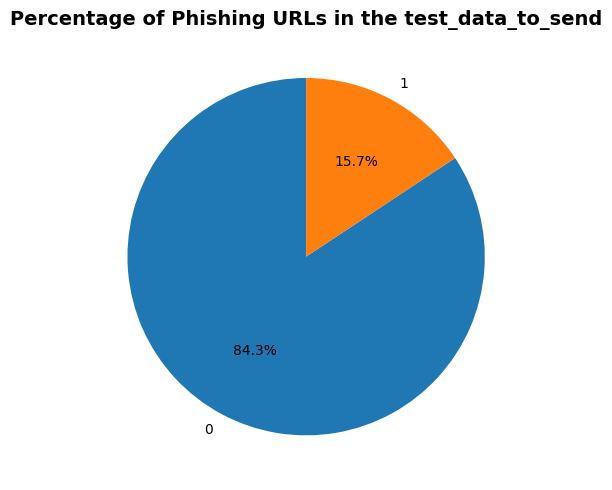

In [ ]:
plot_label_pie(test_data_to_send_CNN, label_col='Label', title='Percentage of Phishing URLs in the test_data_to_send')

4.   LSTM:


In [ ]:
#avec le tokenizer d'entrainement
test_padded_lstm = pad_sequences(test_sequences_cnn, padding="post")

lstm_predictions_prob = model_lstm.predict(test_padded_lstm)

test_data_to_send_LSTM = test_data_to_send.copy()
test_data_to_send_LSTM['Label'] = (lstm_predictions_prob > 0.5).astype(int).flatten()

test_data_to_send_LSTM.head()

1785/1785 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step


,URL,Label
0,gracechurchstaffordsprings.org/,0
1,trailers.apple.com/trailers/wb/iamlegendawaken...,0
2,baseball-almanac.com/players/player.php?p=lowe...,0
3,lib.berkeley.edu/MRC/scifibib.html,0
4,syamasahithi.com/8fh34f3,1


In [ ]:
test_data_to_send.head()#checked

,URL
0,gracechurchstaffordsprings.org/
1,trailers.apple.com/trailers/wb/iamlegendawaken...
2,baseball-almanac.com/players/player.php?p=lowe...
3,lib.berkeley.edu/MRC/scifibib.html
4,syamasahithi.com/8fh34f3


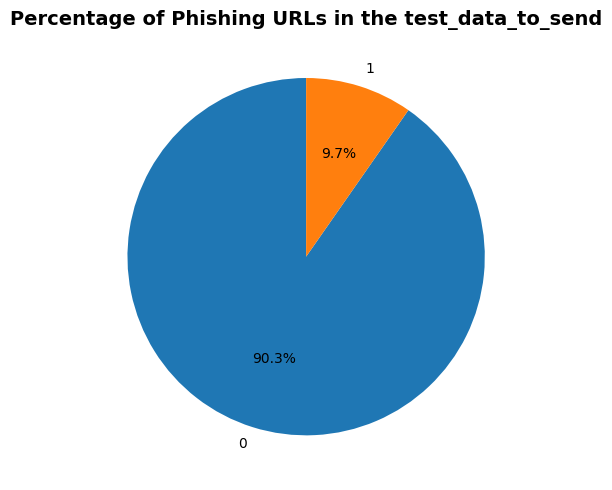

In [ ]:
plot_label_pie(test_data_to_send_LSTM, label_col='Label', title='Percentage of Phishing URLs in the test_data_to_send')

5.   Mixed Model: we can mix since we used the same X_train to train every model. (no model has seen X_test yet)


In the comparative analysis I noticed that the CNN had high precision and LR model had high recall, naturally i tried mixing both to see what we would get:

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

lr_probs_test = pipeline_LR.predict_proba(X_test)[:, 1]

test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded_sequences = pad_sequences(test_sequences, maxlen=input_length, padding="post")

cnn_probs_test = model_cnn.predict(test_padded_sequences)
if cnn_probs_test.ndim > 1:
    cnn_probs_test = cnn_probs_test.ravel()

lstm_probs_test = model_lstm.predict(test_padded_sequences)
if lstm_probs_test.ndim > 1:
    lstm_probs_test = lstm_probs_test.ravel()

#best combination 0.94 f1_score
mixed_model_prediction_test = (0.6 * lr_probs_test + 0.3 * cnn_probs_test + 0.1 * lstm_probs_test  > 0.5).astype(int)

print("Classification Report for Mixed Model (evaluated on X_test):")
print(classification_report(y_test, mixed_model_prediction_test))

1589/1589 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1589/1589 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step
Classification Report for Mixed Model (evaluated on X_test):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     45007
           1       0.94      0.93      0.94      5818

    accuracy                           0.99     50825
   macro avg       0.97      0.96      0.96     50825
weighted avg       0.99      0.99      0.99     50825



Now this seems to be the model, best fit to apply and trust on test_data_to_send.

---

applying it to test_data_to_send:

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

lr_probs = pipeline_LR.predict_proba(test_data_to_send['URL'])[:, 1]
rf_probs = pipeline_RF.predict_proba(test_data_to_send['URL'])[:, 1]

test_sequences = tokenizer.texts_to_sequences(test_data_to_send['URL'])
test_padded_sequences = pad_sequences(test_sequences, maxlen=input_length, padding="post")

cnn_probs = model_cnn.predict(test_padded_sequences)
cnn_probs = cnn_probs.ravel()

lstm_probs = model_lstm.predict(test_padded_sequences)
lstm_probs = lstm_probs.ravel()


mixed_model_prediction = (0.6 * lr_probs + 0.3 * cnn_probs + 0.1 * lstm_probs > 0.5).astype(int)

results = test_data_to_send.copy()


results['CNN_pred'] = (cnn_probs > 0.5).astype(int)
results['LSTM_pred'] = (lstm_probs > 0.5).astype(int)
results['LR_pred'] = pipeline_LR.predict(test_data_to_send['URL'])
results['RF_pred'] = pipeline_RF.predict(test_data_to_send['URL'])
results['Ensemble_pred'] = mixed_model_prediction

results.head()

1785/1785 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step


,URL,CNN_pred,LSTM_pred,LR_pred,RF_pred,Ensemble_pred
0,gracechurchstaffordsprings.org/,0,0,0,0,0
1,trailers.apple.com/trailers/wb/iamlegendawaken...,1,0,0,0,0
2,baseball-almanac.com/players/player.php?p=lowe...,0,0,0,0,0
3,lib.berkeley.edu/MRC/scifibib.html,0,0,0,0,0
4,syamasahithi.com/8fh34f3,1,1,1,1,1


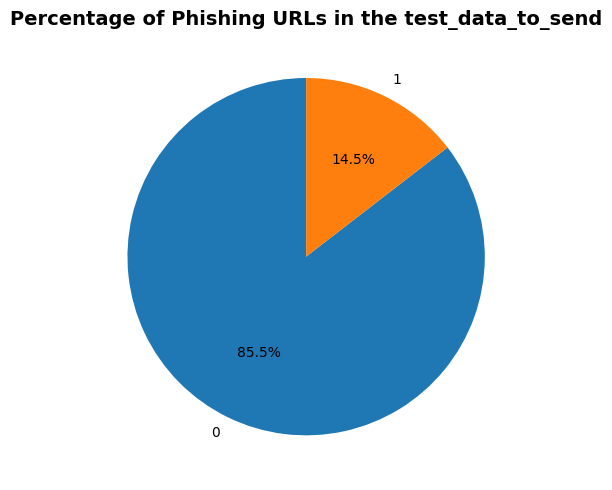

In [ ]:
plot_label_pie(results, label_col='Ensemble_pred', title='Percentage of Phishing URLs in the test_data_to_send')

In [ ]:
results.loc[results["CNN_pred"]!=results["Ensemble_pred"]]


,URL,CNN_pred,LSTM_pred,LR_pred,RF_pred,Ensemble_pred
1,trailers.apple.com/trailers/wb/iamlegendawaken...,1,0,0,0,0
14,www.ess.co.at/IQEM/,0,0,1,0,1
19,myspace.com/seiu_uhw,0,0,1,1,1
95,twitter.com/bgtennisnation,1,0,0,0,0
104,wn.com/Lebeau,1,1,0,1,0
...,...,...,...,...,...,...
56966,wn.com/University_of_Pretoria,1,0,0,0,0
56973,reverbnation.com/blackguard,1,0,0,0,0
57011,ndye.org/seun/index.php,0,0,1,1,1
57037,twitter.com/GeorgeStevens,1,0,0,0,0


In [ ]:
results.loc[results["LR_pred"]!=results["Ensemble_pred"]]


,URL,CNN_pred,LSTM_pred,LR_pred,RF_pred,Ensemble_pred
12,flickr.com/photos/26984546@N07/sets/7215762065...,0,0,1,0,0
35,tulane.simple-url.com/,0,0,1,0,0
43,www.componentsoftware.com/csrcs/,0,0,1,0,0
56,itm38208929933.0fees.org/,1,1,0,0,1
68,www.gael.fr/derby/,0,0,1,1,0
...,...,...,...,...,...,...
56999,myspace.com/debbe_dunning,0,0,1,0,0
57002,profiles.google.com/peggyhealydoherty,0,0,1,0,0
57007,persona.rin.ru/eng/view/f/0/25097/stephen-arroyo,0,0,1,0,0
57014,giftsministries.org/,0,0,1,0,0


In [ ]:
test_data_to_send.head()#checked to not alter

,URL
0,gracechurchstaffordsprings.org/
1,trailers.apple.com/trailers/wb/iamlegendawaken...
2,baseball-almanac.com/players/player.php?p=lowe...
3,lib.berkeley.edu/MRC/scifibib.html
4,syamasahithi.com/8fh34f3


saving test_data_to_send:

The test_dataset_to_send.csv file with an added column is_phishing_prediction
containing binary values (1: bad/phishing, 0: good/legit)

In [ ]:
test_data_to_send_ensemble = test_data_to_send.copy()
test_data_to_send_cnn = test_data_to_send.copy()

test_data_to_send_ensemble['is_phishing_prediction'] = results['Ensemble_pred']
test_data_to_send_cnn['is_phishing_prediction'] = results['CNN_pred']

test_data_to_send_ensemble.to_csv('test_dataset_to_send_ensemble_Anes_ABDOU.csv', index=False)
test_data_to_send_cnn.to_csv('test_dataset_to_send_cnn_Anes_ABDOU.csv', index=False)

In [ ]:
from google.colab import files

files.download('test_dataset_to_send_ensemble_Anes_ABDOU.csv')
files.download('test_dataset_to_send_cnn_Anes_ABDOU.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

FINAL:

In conclusion, I really enjoyed working on this project. That said, from a performance perspective, Logistic Regression performed surprisingly well, especially given its low computational cost and fast training time. Random Forest, particularly during hyperparameter tuning, took more time than the deep learning models because it relies on CPU-based computations.

I chose a lightweight CNN (few layers) with only 10 epochs to test its performance, as I was concerned about resource usage and under time pressure. The same cautious approach was applied to the LSTM model.

In the end, the CNN performed best on its own, but the overall best model was an ensemble, combining predictions as follows:
`0.6 * prob_LR + 0.3 * prob_CNN + 0.1 * prob_LSTM`,
achieving a satisfying F1-score of 0.94, successfully balancing between not blocking legitimate sites and not missing phishing threats.


What is the next step ?

1.   We can engineer the database to add more columns to feed specific patterns to ML algorithms.

2.   Add Layers to the CNN, train it with more epochs, calibrate some Hyperparameters.

3.   Write a function that tries all possible combinations of DL & ML models to get the best Ensemble Algorithm.

---

###Thank you for your attention.
